In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import copy
# initialize the codespace with only A-stabilizer 

def lattice_space(H, L):
    lattice = np.zeros((H, L))
    for i in range(H):
        for j in range(L):
            if i % 3 == 0 and j % 3 != 0:
                lattice[i][j] = 1
            if i % 3 == 1 and j % 3 != 2:
                lattice[i][j] = 1
            if i % 3 == 2 and j % 3 != 1:
                lattice[i][j] = 1
    return lattice
import random

def energy(lattice):
    
    H = lattice.shape[0]
    L = lattice.shape[1]
    energy = 0
    for i in range(H):
        for j in range(L):
            # Periodic boundary conditions
            right = lattice[(i+1)% H, (j+1) % L]
            down  = lattice[(i+1) % H, j]
            energy +=  (lattice[i, j] + right + down)% 2
    return energy

def compute_dE(lattice_, i, j):
    # Sum over four neighbors with periodic boundaries
    lattice = lattice_.copy()
    H = lattice.shape[0]
    L = lattice.shape[1]
    s = lattice[i, j]
    ds = (s+1)%2
    left = lattice[i, (j-1)%L] + lattice[(i-1)%H, (j-1)%L]
    right = lattice[(i-1)%H, j] + lattice[i, (j+1)%L]
    bottom = lattice[(i+1)%H, j] + lattice[(i+1)%H, (j+1)%L]
    E  = (left+s)%2 + (right+s)%2 + (bottom+s)%2
    E_new = (left+ds)%2 + (right+ds)%2 + (bottom+ds)%2
    dE = (E_new - E)
    if dE == 0:
        raise ValueError("No change in energy")
    return dE

def monte_carlo_error(lattice, num_steps, error_rate):
    H = lattice.shape[0]
    L = lattice.shape[1]
    for _ in range(num_steps):
        # i = random.randint(0, H - 1)
        # j = random.randint(0, L - 1)
        # r = random.random()
        # if r < error_rate:
        #     # Flip the qubit
        #     lattice[i, j] = (lattice[i, j] + 1) % 2
            
        for i in range(H):
            for j in range(L):
                r = random.random()
                if r < error_rate:
                    # Flip the qubit
                    lattice[i, j] = (lattice[i, j] + 1) % 2
            

    return lattice
    
def nonzero_random():
    r = random.random()
    while r == 0.0:
        r = random.random()
    return r

def bkl(lattice, steps, p, q,  configs= None):

    
    if configs     is None: configs     = []
    
    f = 1e-8
    H = lattice.shape[0]
    L = lattice.shape[1]
    time_list = []
    for step in range(steps):
        # Create a dictionary to group spin flips by their energy change (dE)
        classes = {0:[] , 1:[]}
        # For each spin, compute its energy change upon flipping
        for i in range(H):
            for j in range(L):
                if lattice[i, j] == 1:
                    classes[1].append((i, j))
                else:
                    classes[0].append((i, j))
        
        # Calculate transition rates for each class:
        # For spins where flipping lowers energy (dE <= 0), acceptance probability is 1;
        # for dE > 0, it is dE*(1-exp(-beta * dE))
        chosen_class = None
        flip = False
        r = random.uniform(0, 2)
        prob_flip_1 = len(classes[1])*p/(H*L)
        prob_flip_0 = len(classes[0])*q/(H*L)
        prob_remain_1 = len(classes[1])*(1-p)/(H*L)
        prob_remain_0 = len(classes[0])*(1-q)/(H*L)

        if r < prob_flip_1:
            chosen_class = 1
            flip = True
        elif r < prob_flip_1 + prob_flip_0:
            chosen_class = 0
            flip = True
        elif r < prob_flip_1 + prob_flip_0 + prob_remain_1:
            chosen_class = 1
            flip = False
        else:
            chosen_class = 0
            flip = False

        if flip:
            i, j = random.choice(classes[chosen_class])
            lattice[i, j] ^= 1 # Flip the spin

        configs.append(copy.deepcopy(lattice))
        rho3 = nonzero_random()
        dT = -1/2 * math.log(rho3)
        time_list.append(dT)
        
    return lattice, configs, time_list


def bkl(lattice, steps, p, q,  configs= None):

    
    if configs     is None: configs     = []
    
    f = 1e-8
    H = lattice.shape[0]
    L = lattice.shape[1]
    time_list = []
    labels = []
    for step in range(steps):
        # Create a dictionary to group spin flips by their energy change (dE)
        classes = {0:[] , 1:[]}
        # For each spin, compute its energy change upon flipping
        for i in range(H):
            for j in range(L):
                if lattice[i, j] == 1:
                    classes[1].append((i, j))
                else:
                    classes[0].append((i, j))
        
        # Calculate transition rates for each class:
        # For spins where flipping lowers energy (dE <= 0), acceptance probability is 1;
        # for dE > 0, it is dE*(1-exp(-beta * dE))
        chosen_class = None
        flip = False
        r = random.uniform(0, 2)
        #====== p : 1->0, q: 0->1 ======
        prob_flip_1 = len(classes[1])*p/(H*L)
        prob_flip_0 = len(classes[0])*q/(H*L)
        prob_remain_1 = len(classes[1])*(1-p)/(H*L)
        prob_remain_0 = len(classes[0])*(1-q)/(H*L)

        if r < prob_flip_1:
            chosen_class = 1
            flip = True
        elif r < prob_flip_1 + prob_flip_0:
            chosen_class = 0
            flip = True
        elif r < prob_flip_1 + prob_flip_0 + prob_remain_1:
            chosen_class = 1
            flip = False
        else:
            chosen_class = 0
            flip = False
        labels.append(chosen_class)
        if flip:
            i, j = random.choice(classes[chosen_class])
            lattice[i, j] ^= 1 # Flip the spin

        configs.append(copy.deepcopy(lattice))
        rho3 = nonzero_random()
        dT = -1/2 * math.log(rho3)
        time_list.append(dT)
        
    return lattice, configs, time_list, labels

def time_bin(time_lists:list, decoder_mag:list):
    """
    Bins the time lists into intervals of size bin_size.
    Returns a list of binned times and their corresponding counts.
    """
    # flatten cumsum lists in one and divide by equllength bins
    flattened_time = np.concatenate(time_lists)
    flattened_mag = np.concatenate(decoder_mag)

    order_time = np.argsort(np.abs(flattened_time))
    flat_sorted_by_mag_time = flattened_time[order_time]
    flat_sorted_by_mag_mag = flattened_mag[order_time]

    nbins = np.array(time_lists).shape[1]
    edges_time = np.linspace(flat_sorted_by_mag_time.min(), flat_sorted_by_mag_time.max(), nbins+1)
    centers_time = 0.5 * (edges_time[:-1] + edges_time[1:])

    edges_mag = np.linspace(flat_sorted_by_mag_mag.min(), flat_sorted_by_mag_mag.max(), nbins+1)
    centers_mag = 0.5 * (edges_mag[:-1] + edges_mag[1:])

    # create bins 
    bin_idx_1 = np.digitize(flat_sorted_by_mag_time, edges_time) - 1
    bin_idx_1 = np.clip(bin_idx_1, 0, nbins-1)

    sums_time   = np.bincount(bin_idx_1, weights=flat_sorted_by_mag_time, minlength=nbins)
    counts_time = np.bincount(bin_idx_1,           minlength=nbins)

    sums_mag   = np.bincount(bin_idx_1, weights=flat_sorted_by_mag_mag, minlength=nbins)
    counts_mag = np.bincount(bin_idx_1,           minlength=nbins)

    means_time = np.empty_like(centers_time)
    means_mag = np.empty_like(centers_mag)
    # normal division where counts>0
    np.divide(sums_time, counts_time, out=means_time, where=(counts_time>0))
    np.divide(sums_mag, counts_mag, out=means_mag, where=(counts_mag>0))
    # fill empty bins with the bin center
    valid = counts_time > 0
    empty = ~valid
    means_time[empty] = centers_time[empty]

    means_mag[empty]    = np.interp(centers_time[empty],
                                    centers_time[valid], means_mag[valid])
    return means_time,  means_mag

def plot_lattice(configs:list, time_list:list, title="Spin 1"):
    mags = np.array([np.sum(np.abs(config)) for config in configs])/configs[0].size
    T = np.cumsum(time_list)
    plt.plot(T, mags, 'o-', label ='spins')
    plt.title(title)
    plt.xlabel('time steps')
    plt.ylabel('spin1 fraction')
    plt.show()



def mc_spin_flip(lattice, steps, p, q, *, mode="random_site", configs=None, sample_every=1, rng=None):
    """
    Standard Monte Carlo for independent 0/1 spins with constant flip probs:
      p: prob(1 -> 0) per attempt
      q: prob(0 -> 1) per attempt

    Args
    ----
    lattice : np.ndarray of shape (H, L), integer 0/1
    steps   : int
        If mode="random_site": number of single-spin attempts (each attempt picks a random site).
        If mode="sweep": number of sweeps (each sweep does N attempts in random order).
    p, q    : float in [0,1]
    mode    : "random_site" or "sweep"
    configs : list to append snapshots (deep copies) to; if None, a new list is created
    sample_every : record to `configs` every this many steps (MC steps in chosen mode)
    rng     : np.random.Generator or Python's random; if None, use Python `random`

    Returns
    -------
    lattice_out, configs, time_list
      lattice_out : np.ndarray final configuration
      configs     : list of np.ndarray snapshots
      time_list   : list of float time increments (sum ≈ number of sweeps)
    """
    if configs is None:
        configs = []

    H, L = lattice.shape
    N = H * L
    lat = lattice.astype(np.uint8, copy=False)

    # clamp probabilities to [0,1] defensively
    p = min(max(p, 0.0), 1.0)
    q = min(max(q, 0.0), 1.0)

    # RNG helpers
    if rng is None:
        rand = random.random
        randint = lambda hi: random.randrange(hi)
        shuffle = random.shuffle
    elif isinstance(rng, np.random.Generator):
        rand = rng.random
        randint = rng.integers
        shuffle = lambda seq: rng.shuffle(seq)
    else:
        # assume Python-like API
        rand = rng.random
        randint = lambda hi: rng.randrange(hi)
        shuffle = rng.shuffle

    time_list = []

    if mode == "random_site":
        dt = 1.0 / N
        for t in range(steps):
            i = randint(H)
            j = randint(L)
            if lat[i, j] == 1:
                if rand() < p:
                    lat[i, j] ^= 1  # flip 1->0
            else:
                if rand() < q:
                    lat[i, j] ^= 1  # flip 0->1

            time_list.append(dt)
            if (t + 1) % sample_every == 0:
                configs.append(lat.copy())

    elif mode == "sweep":
        dt = 1.0
        idx = np.arange(N)
        for s in range(steps):
            shuffle(idx)  # random order each sweep
            # visit each site once
            for k in idx:
                i, j = divmod(int(k), L)
                if lat[i, j] == 1:
                    if rand() < p:
                        lat[i, j] ^= 1
                else:
                    if rand() < q:
                        lat[i, j] ^= 1
            time_list.append(dt)
            if (s + 1) % sample_every == 0:
                configs.append(lat.copy())
    else:
        raise ValueError("mode must be 'random_site' or 'sweep'")

    return lat, configs, time_list

In [24]:
seeds = 200
steps = 2000
p = 0.4 # flip rate for 0->1
q = 0.5 # flip rate for 1->0
H = 6
L =6


lattice = np.zeros((H, L), dtype=int)
mag_lists = np.zeros((seeds, steps))
time_lists = np.zeros((seeds, steps))
fracs = np.zeros(seeds)
for seed in range(seeds):
    random.seed(seed)
    np.random.seed(seed)
    lattice, configs, time_list, labels = bkl(lattice, steps, p, q)
    mags = np.array([np.sum(np.abs(config)) for config in configs])/configs[0].size
    mag_lists[seed] = mags
    time_lists[seed] = np.cumsum(time_list)
    spin_1s = np.where(np.array(labels) == 1)[0]
    fracs[seed] = sum(np.array(time_list)[spin_1s])/sum(time_list)

#       time binning
mean_times, mean_mags = time_bin(time_lists, mag_lists)
mean_frac = np.mean(fracs)

#       plotting
plt.plot(mean_times, mean_mags, 'o-', label = f'spins 1 with p= {p}, q= {q}')
plt.axhline(y=q/(p+q), color='r', linestyle='--', label =r'Spin 1 frac = $\frac{q}{p+q}$')
plt.axhline(y=mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.3f}')
plt.title('BKL Spin 1 for two level system p: 1->0, q: 0->1')
plt.xlabel('Physical time steps')
plt.ylabel('Spin 1 fraction')
plt.legend()
plt.show()

IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

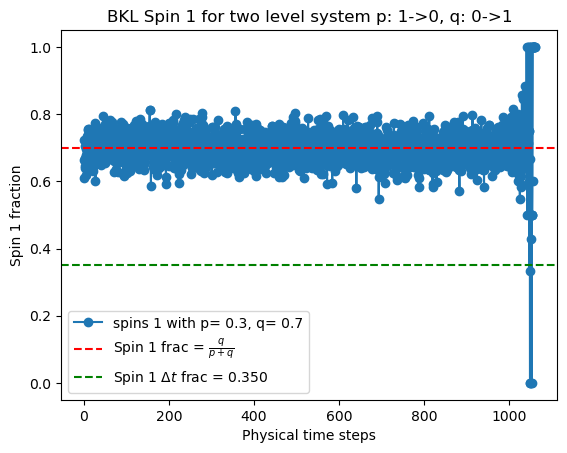

In [29]:
seeds = 200
steps = 2000
p = 0.3 # flip rate for 0->1
q = 0.7 # flip rate for 1->0
H = 1
L =1


lattice = np.zeros((H, L), dtype=int)
mag_lists = np.zeros((seeds, steps))
time_lists = np.zeros((seeds, steps))
fracs = np.zeros(seeds)
for seed in range(seeds):
    random.seed(seed)
    np.random.seed(seed)
    lattice, configs, time_list, labels = bkl(lattice, steps, p, q)
    mags = np.array([np.sum(np.abs(config)) for config in configs])/configs[0].size
    mag_lists[seed] = mags
    time_lists[seed] = np.cumsum(time_list)
    spin_1s = np.where(np.array(labels) == 1)[0]
    fracs[seed] = sum(np.array(time_list)[spin_1s])/sum(time_list)

#       time binning
mean_times, mean_mags = time_bin(time_lists, mag_lists)
mean_frac = np.mean(fracs)

#       plotting
plt.plot(mean_times, mean_mags, 'o-', label = f'spins 1 with p= {p}, q= {q}')
plt.axhline(y=q/(p+q), color='r', linestyle='--', label =r'Spin 1 frac = $\frac{q}{p+q}$')
plt.axhline(y=mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.3f}')
plt.title('BKL Spin 1 for two level system p: 1->0, q: 0->1')
plt.xlabel('Physical time steps')
plt.ylabel('Spin 1 fraction')
plt.legend()
plt.show()

In [21]:
print(fracs[1])

0.2843656583598364


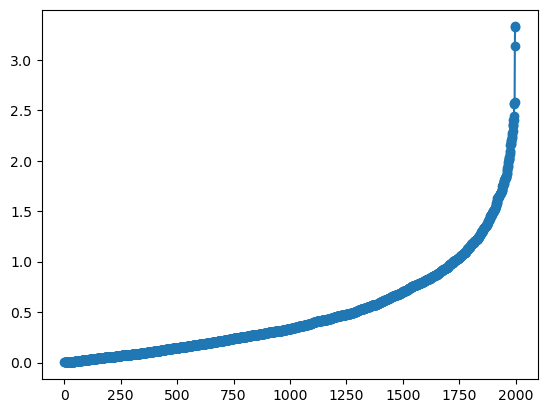

In [19]:
id = sorted(range(len(time_list)), key=lambda i: abs(time_list[i])) 
exp_dist = [time_list[i] for i in id]
plt.plot(exp_dist, 'o-')
# plt.plot([np.exp(i/1000) for i in range(2000)], 'r--')
# plt.xscale('log')
# plt.yscale('log')

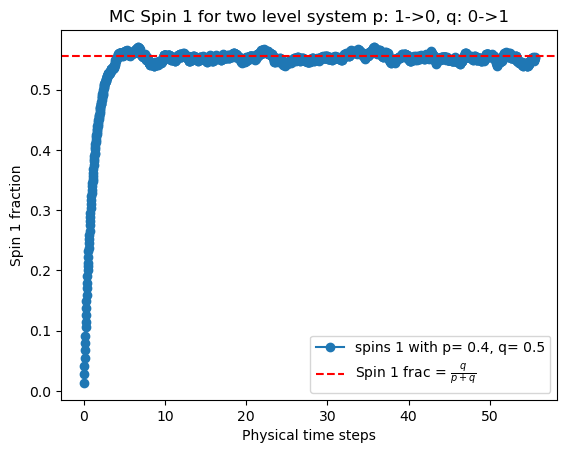

In [39]:
seeds = 200
steps = 2000
p = 0.4 # flip rate for 0->1
q = 0.5 # flip rate for 1->0
H = 6
L =6


lattice1 = np.zeros((H, L), dtype=int)
mag_lists1 = np.zeros((seeds, steps))
time_lists1 = np.zeros((seeds, steps))
for seed in range(seeds):
    random.seed(seed)
    np.random.seed(seed)
    lattice, configs, time_list = mc_spin_flip(lattice1, steps, p, q)
    mags = np.array([np.sum(np.abs(config)) for config in configs])/configs[0].size
    mag_lists1[seed] = mags
    time_lists1[seed] = np.cumsum(time_list)

#       time binning
mean_times1, mean_mags1 = time_bin(time_lists1, mag_lists1)

#       plotting
plt.plot(mean_times1, mean_mags1, 'o-', label = f'spins 1 with p= {p}, q= {q}')
plt.axhline(y=q/(p+q), color='r', linestyle='--', label =r'Spin 1 frac = $\frac{q}{p+q}$')
plt.title('MC Spin 1 for two level system p: 1->0, q: 0->1')
plt.xlabel('Physical time steps')
plt.ylabel('Spin 1 fraction')
plt.legend()
plt.show()

In [51]:
def correlation(spin_config: list):
    spin_conf = np.array(spin_config.copy())
    spin_conf = 1 - 2 * spin_conf  # Convert to -1, 1
    T, H, L = spin_conf.shape
    N = H * L
    # S_T = np.mean(spin_conf)
    # S_T = 1/2
    # correlation = []
    trajs = 200
    correlation = np.zeros((trajs,T-trajs))
    for t0 in range(trajs):
        S_T = np.full((H,L), np.mean(spin_conf[t0]))
        for tau in range(T-trajs):
            # For each tau, compute the correlation between t0 and t0+tau
            s0 = spin_conf[t0]        # shape (H, L)
            st = spin_conf[tau]  # shape (H, L)
            # Correlator: <S(t0) S(t0+tau)> - <S>^2, averaged over sites
            # Correlator: <(S(t0) - <S>) (S(t0+tau) - <S>)>, averaged over sites
            # corr = np.mean(s0 * st) - S_T ** 2
            corr = np.mean((((s0 -S_T)*(st - S_T))))  
            correlation[t0][tau] = corr
    
    return T-trajs, np.mean(correlation, axis=0)

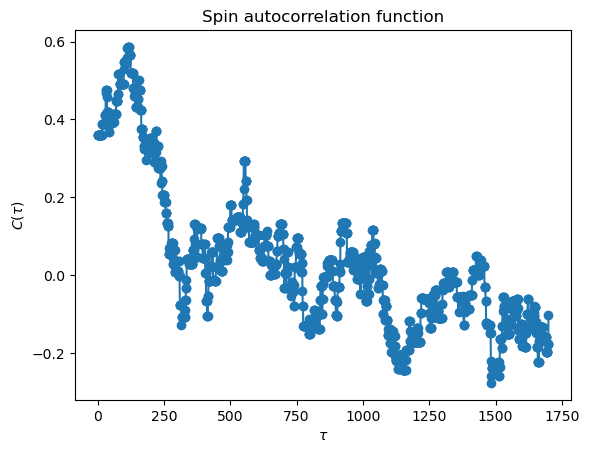

In [52]:
t, corr = correlation(configs[100:])
plt.plot(np.arange(t), corr, 'o-')
plt.title('Spin autocorrelation function')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$C(\tau)$')
plt.show()

